## Obtain data to be then used in the empirical part

In [1]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [55]:
# Parameter calibration
a = 1.02 # mean of the dividend process
gamma = 8.0 # risk aversion
sigma = 0.001 # std dev of the dividend process
sigma_x = 0.001 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-6)  # small constant to ensure positivity
constant_gain = 0.01  # constant gain parameter for learning
lambda_lasso = 0.1  # lasso penalty parameter
print(kappa, w)

0.8193511660179875 0.19676376071302668


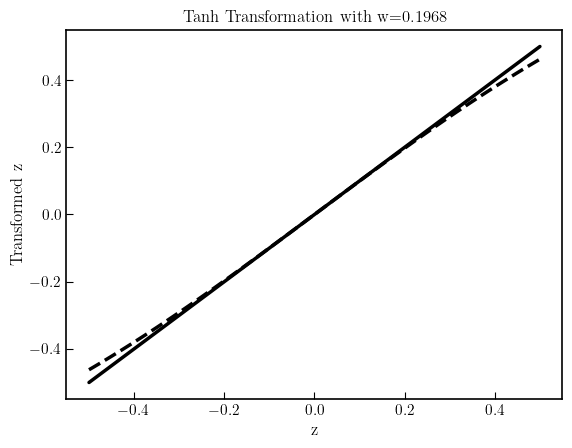

In [56]:
#visualzie the tanh transformation around small values
z = np.linspace(-0.5, 0.5, 100)
plt.plot(z, w * np.tanh(z)/w, linestyle='dashed', label='Tanh Transformation')
plt.plot(z, z)
plt.xlabel('z')
plt.ylabel('Transformed z')
plt.title('Tanh Transformation with w={:.4f}'.format(w))
plt.grid()
plt.show()

In [57]:
def lasso_from_beta_ols(beta_ols, lambda_param):
    """
    Apply Lasso shrinkage to OLS coefficients.
    
    Parameters:
    beta_ols (np.ndarray): OLS coefficients.
    lambda_param (float): Regularization parameter.
    
    Returns:
    np.ndarray: Lasso-shrunken coefficients.
    """
    return np.sign(beta_ols) * np.maximum(np.abs(beta_ols) - lambda_param, 0)

In [58]:
def multivariate_CGL_lasso(T, K, sigma_x, sigma, kappa, w, lambda_lasso):
    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta = np.zeros((T, K, 1)) # coefficients for the observable variables
    beta_lasso = np.zeros((T, K, 1)) # lasso-shrunken coefficients for the observable variables
    M = np.zeros((T, K, K))
    r = np.zeros(T)

    #Starting values
    beta[0, :, 0] = np.random.normal(0, 0.001, K) #small perturbation around REE
    beta[1, :, 0] = np.random.normal(0, 0.001, K)
    M[0, :, :] = np.eye(K) * sigma_x ** 2 # initial variance of the observable variables 
    r[1] = np.random.normal(0, 0.0001)

    for t in range(2, T):
        # update M
        M[t-1, :, :] = M[t-2, :, :] + (np.outer(x[t-2, :], x[t-2, :]) - M[t-2, :, :]) * constant_gain
        # update beta using RLS
        beta[t, :, 0] = beta[t-1, :, 0] + constant_gain * np.linalg.inv( M[t-1, :, :]) @ (x[t-2, :].reshape(-1, 1) * r[t-1] - (x[t-2, :].reshape(-1, 1) @ x[t-2, :].reshape(1, -1)) @ beta[t-1, :, 0].reshape(-1, 1)).flatten()
        # compute expected returns
        beta_lasso[t, :, 0] = lasso_from_beta_ols(beta[t, :, 0], lambda_lasso)
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta, r, beta_lasso, x

In [59]:
#generate long time series for K = 20 and T = 10000
beta, r, beta_lasso, x = multivariate_CGL_lasso(T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59432/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


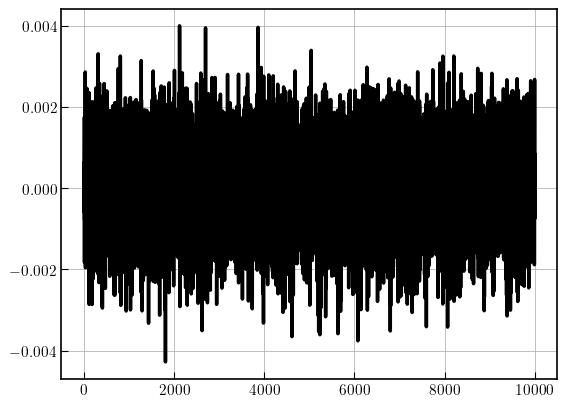

In [60]:
fig, ax = plt.subplots()
ax.plot(r)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59432/1461377494.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


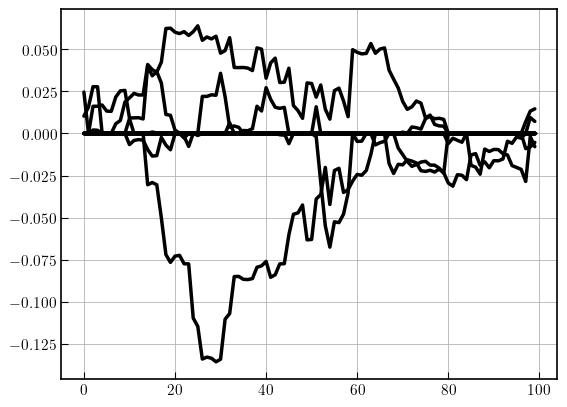

In [61]:
zoom_in = slice(100, 200)
fig, ax = plt.subplots()
for k in range(20):
    ax.plot(beta_lasso[zoom_in, k, 0])
ax.legend()


In [63]:
#create a dataset with x and r
#generate fictituous dates
import pandas as pd
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')
data = pd.DataFrame(data=x, index=dates, columns=[f'x_{i+1}' for i in range(x.shape[1])])
data['r'] = r
data.to_csv('simulation_data.csv')